In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

import os
os.chdir("..")

from src.utils.pca import PCA_Util
from src.utils.data_retrieval import get_pokedex_table

___
# All pokemon PCA
___

In [2]:
# get pokemon df
df = get_pokedex_table(only_fully_evolved=False, include_moves=False)

In [3]:
df

,pokemon_name,hp,attack,defense,sp_attack,sp_defense,speed
0,Bulbasaur,45,49,49,65,65,45
1,Ivysaur,60,62,63,80,80,60
2,Venusaur,80,82,83,100,100,80
3,Charmander,39,52,43,60,50,65
4,Charmeleon,58,64,58,80,65,80
...,...,...,...,...,...,...,...
1020,Raging-bolt,125,73,91,137,89,75
1021,Iron-boulder,90,120,80,68,108,124
1022,Iron-crown,90,72,100,122,108,98
1023,Terapagos,90,65,85,65,85,60


In [4]:
PCA_transformer_all_pokemon = PCA_Util()
scaled_df = PCA_transformer_all_pokemon.fit(df)

In [5]:
PCA_transformer_all_pokemon.print_loadings()


PC1 (44.1% variance):
  hp: 0.4243
  attack: 0.4344
  defense: 0.3922
  sp_attack: 0.4298
  sp_defense: 0.4439
  speed: 0.3093

PC2 (18.4% variance):
  hp: -0.0992
  attack: -0.0701
  defense: -0.5831
  sp_attack: 0.3647
  sp_defense: -0.1605
  speed: 0.6975

PC3 (14.7% variance):
  hp: 0.2644
  attack: 0.6423
  defense: -0.0261
  sp_attack: -0.3911
  sp_defense: -0.5842
  speed: 0.1503

PC4 (11.2% variance):
  hp: 0.7739
  attack: -0.1971
  defense: -0.4429
  sp_attack: 0.1569
  sp_defense: -0.0476
  speed: -0.3730

PC5 (7.1% variance):
  hp: -0.2655
  attack: 0.2386
  defense: 0.0789
  sp_attack: 0.7051
  sp_defense: -0.4409
  speed: -0.4180

PC6 (4.5% variance):
  hp: 0.2660
  attack: -0.5459
  defense: 0.5506
  sp_attack: 0.0866
  sp_defense: -0.4891
  speed: 0.2853


{'PC1': {'hp': np.float64(0.4243138699183961),
  'attack': np.float64(0.4343990627274924),
  'defense': np.float64(0.3922048208925426),
  'sp_attack': np.float64(0.42980272472300174),
  'sp_defense': np.float64(0.4438917311915666),
  'speed': np.float64(0.3092900279114028)},
 'PC2': {'hp': np.float64(-0.0992000837691965),
  'attack': np.float64(-0.07010310488315016),
  'defense': np.float64(-0.5830502324709427),
  'sp_attack': np.float64(0.364694562898284),
  'sp_defense': np.float64(-0.16053581096765648),
  'speed': np.float64(0.6975123322715466)},
 'PC3': {'hp': np.float64(0.26436674780935826),
  'attack': np.float64(0.6422976059018727),
  'defense': np.float64(-0.026141897546745535),
  'sp_attack': np.float64(-0.3911116707682914),
  'sp_defense': np.float64(-0.5842196451104712),
  'speed': np.float64(0.15033188801419406)},
 'PC4': {'hp': np.float64(0.773939678309445),
  'attack': np.float64(-0.19706473104608302),
  'defense': np.float64(-0.4429389256684683),
  'sp_attack': np.float6

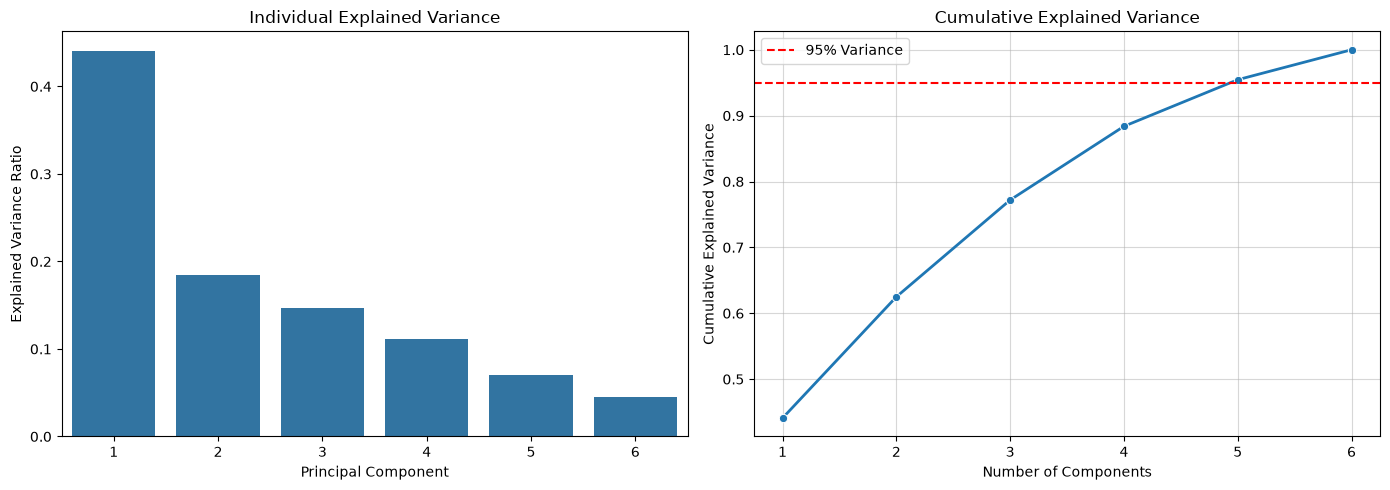

(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Individual Explained Variance'}, xlabel='Principal Component', ylabel='Explained Variance Ratio'>,
        <Axes: title={'center': 'Cumulative Explained Variance'}, xlabel='Number of Components', ylabel='Cumulative Explained Variance'>],
       dtype=object))

In [6]:
PCA_transformer_all_pokemon.scree_plot()

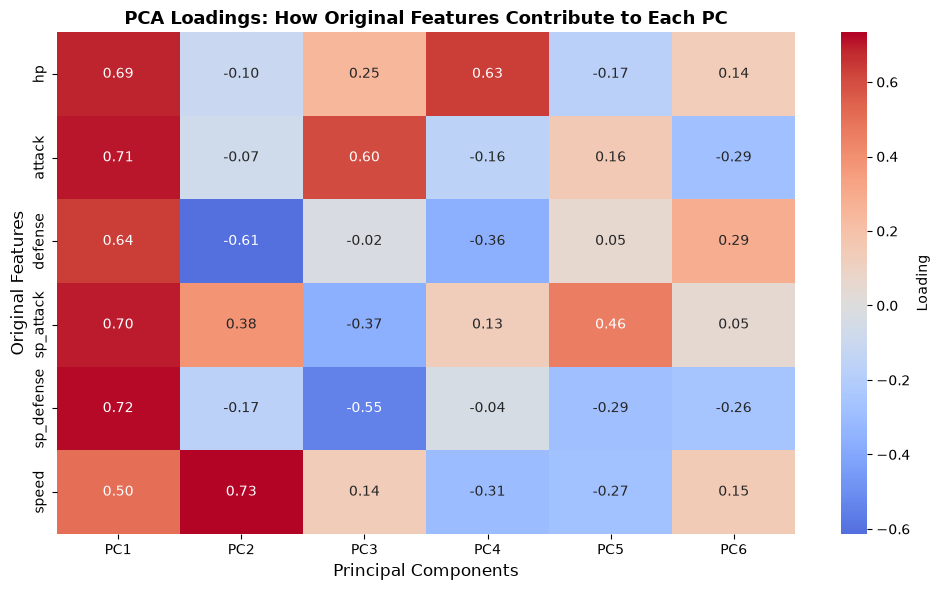

In [7]:
PCA_transformer_all_pokemon.heat_map()

In [8]:
from ipywidgets import FloatSlider, interactive_output, HBox, VBox

sliders = [
    FloatSlider(value=0, min=0, max=len(PCA_transformer_all_pokemon.feature_names), step=1, description=f'PC{i+1}:', continuous_update=False)
    for i in range(2)  # 3 dimensions
]

def update_output(**slider_values):
    slider_dict = {f"PC_{i}":int(slider) for i, (key, slider) in enumerate(slider_values.items())}
    PCA_transformer_all_pokemon.biplot(**slider_dict)

output = interactive_output(update_output, {f'slider{i}': slider for i, slider in enumerate(sliders)})
display(VBox(sliders + [output]))

# PCA_transformer_all_pokemon.biplot(0,1)

___
# Only fully evolved pokemon
___


In [9]:
# get pokemon df
df = get_pokedex_table(only_fully_evolved=True, include_moves=False)

In [10]:
df

,pokemon_name,hp,attack,defense,sp_attack,sp_defense,speed
0,Venusaur,80,82,83,100,100,80
1,Charizard,78,84,78,109,85,100
2,Blastoise,79,83,100,85,105,78
3,Butterfree,60,45,50,90,80,70
4,Beedrill,65,90,40,45,80,75
...,...,...,...,...,...,...,...
529,Raging-bolt,125,73,91,137,89,75
530,Iron-boulder,90,120,80,68,108,124
531,Iron-crown,90,72,100,122,108,98
532,Terapagos,90,65,85,65,85,60


In [11]:
PCA_transformer_all_pokemon = PCA_Util()
scaled_df = PCA_transformer_all_pokemon.fit(df)

In [12]:
PCA_transformer_all_pokemon.print_loadings()


PC1 (25.8% variance):
  hp: 0.1081
  attack: 0.2160
  defense: 0.6383
  sp_attack: -0.4026
  sp_defense: 0.1683
  speed: -0.5863

PC2 (23.4% variance):
  hp: -0.2093
  attack: -0.5825
  defense: 0.1334
  sp_attack: 0.3512
  sp_defense: 0.6718
  speed: -0.1563

PC3 (18.5% variance):
  hp: 0.7743
  attack: 0.2973
  defense: 0.0346
  sp_attack: 0.5091
  sp_defense: 0.2273
  speed: 0.0056

PC4 (15.1% variance):
  hp: -0.4343
  attack: 0.5144
  defense: 0.4433
  sp_attack: 0.2258
  sp_defense: 0.2210
  speed: 0.5004

PC5 (10.0% variance):
  hp: -0.3045
  attack: 0.0816
  defense: 0.0934
  sp_attack: 0.6335
  sp_defense: -0.4903
  speed: -0.5002

PC6 (7.2% variance):
  hp: 0.2523
  attack: -0.5044
  defense: 0.6069
  sp_attack: 0.0548
  sp_defense: -0.4237
  speed: 0.3622


{'PC1': {'hp': np.float64(0.10814011215019458),
  'attack': np.float64(0.21599796271192784),
  'defense': np.float64(0.6383262730592582),
  'sp_attack': np.float64(-0.402645311087706),
  'sp_defense': np.float64(0.1683106223485295),
  'speed': np.float64(-0.5862921227804891)},
 'PC2': {'hp': np.float64(-0.20932009647341637),
  'attack': np.float64(-0.5824878496811217),
  'defense': np.float64(0.13339743971376072),
  'sp_attack': np.float64(0.3512174751612934),
  'sp_defense': np.float64(0.6717959574523847),
  'speed': np.float64(-0.15631571244118614)},
 'PC3': {'hp': np.float64(0.7742966102417408),
  'attack': np.float64(0.2972946099574469),
  'defense': np.float64(0.03457031893731143),
  'sp_attack': np.float64(0.5091019210867651),
  'sp_defense': np.float64(0.22730902715449444),
  'speed': np.float64(0.00560423293720369)},
 'PC4': {'hp': np.float64(-0.4342913948032303),
  'attack': np.float64(0.5143869573599856),
  'defense': np.float64(0.4433123132347268),
  'sp_attack': np.float64(

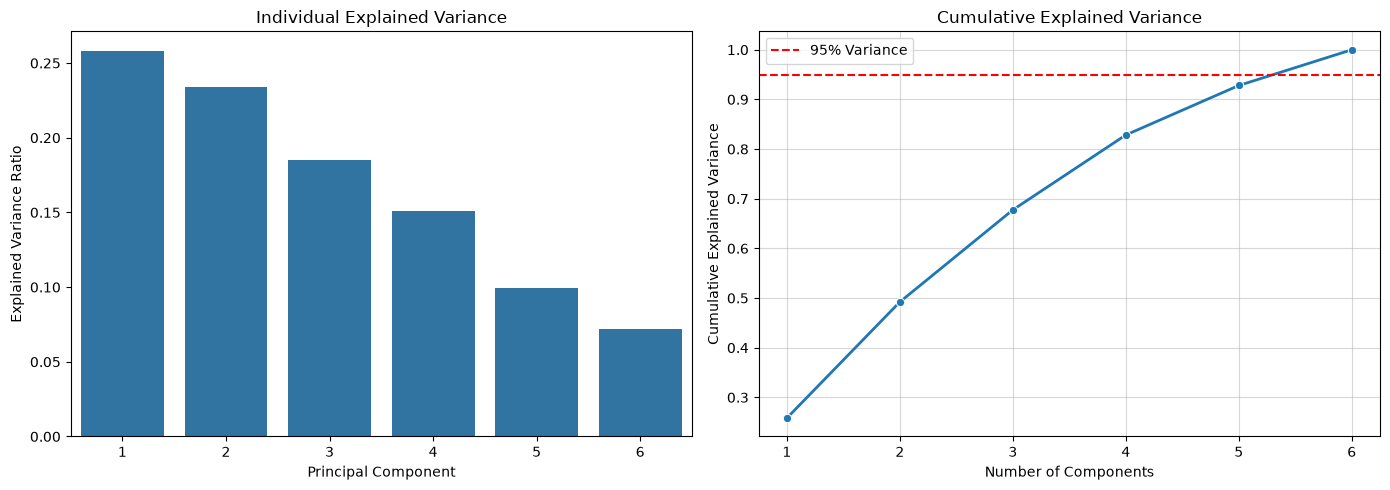

(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Individual Explained Variance'}, xlabel='Principal Component', ylabel='Explained Variance Ratio'>,
        <Axes: title={'center': 'Cumulative Explained Variance'}, xlabel='Number of Components', ylabel='Cumulative Explained Variance'>],
       dtype=object))

In [13]:
PCA_transformer_all_pokemon.scree_plot()

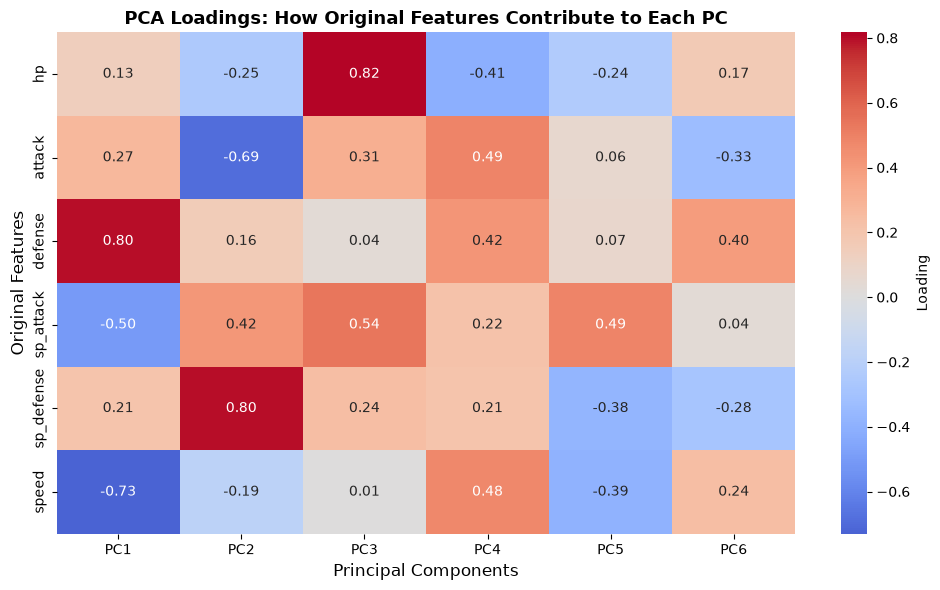

In [14]:
PCA_transformer_all_pokemon.heat_map()

In [15]:
from ipywidgets import FloatSlider, interactive_output, HBox, VBox

sliders = [
    FloatSlider(value=0, min=0, max=len(PCA_transformer_all_pokemon.feature_names), step=1, description=f'PC{i+1}:', continuous_update=False)
    for i in range(2)  # 3 dimensions
]

def update_output(**slider_values):
    slider_dict = {f"PC_{i}":int(slider) for i, (key, slider) in enumerate(slider_values.items())}
    PCA_transformer_all_pokemon.biplot(**slider_dict)

output = interactive_output(update_output, {f'slider{i}': slider for i, slider in enumerate(sliders)})
display(VBox(sliders + [output]))

# PCA_transformer_all_pokemon.biplot(0,1)

___
# All Fully evolved pokemon with learned moves encoded
___

In [17]:
df = get_pokedex_table(only_fully_evolved=True, include_moves=True,)

In [18]:
df

,pokemon_name,hp,attack,defense,sp_attack,sp_defense,speed,Absorb,Acid,Acid-armor,...,Wood-hammer,Work-up,Worry-seed,Wrap,Wring-out,X-scissor,Yawn,Zap-cannon,Zen-headbutt,Zing-zap
0,Venusaur,80,82,83,100,100,80,False,False,False,...,False,True,True,False,False,False,False,False,False,False
1,Charizard,78,84,78,109,85,100,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,Blastoise,79,83,100,85,105,78,False,False,False,...,False,True,False,False,False,False,True,False,True,False
3,Butterfree,60,45,50,90,80,70,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Beedrill,65,90,40,45,80,75,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529,Raging-bolt,125,73,91,137,89,75,False,False,False,...,False,False,False,False,False,False,False,True,False,False
530,Iron-boulder,90,120,80,68,108,124,False,False,False,...,False,False,False,False,False,True,False,False,True,False
531,Iron-crown,90,72,100,122,108,98,False,False,False,...,False,False,False,False,False,True,False,False,True,False
532,Terapagos,90,65,85,65,85,60,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [26]:
PCA_transformer_all_pokemon = PCA_Util(n_components=100)
scaled_df = PCA_transformer_all_pokemon.fit(df)

In [27]:
PCA_transformer_all_pokemon.print_loadings()


PC1 (3.4% variance):
  hp: -0.0250
  attack: -0.0958
  defense: -0.0446
  sp_attack: 0.0705
  sp_defense: 0.0525
  speed: 0.0169
  Absorb: 0.0135
  Acid: -0.0024
  Acid-armor: 0.0074
  Acid-spray: -0.0061
  Acrobatics: 0.0071
  Acupressure: 0.0023
  Aerial-ace: -0.0151
  Aeroblast: 0.0089
  After-you: 0.0527
  Agility: 0.0078
  Air-cutter: 0.0179
  Air-slash: 0.0169
  Alluring-voice: 0.0550
  Ally-switch: 0.1177
  Amnesia: 0.0152
  Anchor-shot: -0.0007
  Ancient-power: -0.0232
  Apple-acid: -0.0020
  Aqua-cutter: -0.0032
  Aqua-jet: -0.0127
  Aqua-ring: -0.0004
  Aqua-step: -0.0033
  Aqua-tail: -0.0332
  Arm-thrust: -0.0236
  Armor-cannon: 0.0055
  Aromatherapy: 0.0427
  Aromatic-mist: 0.0347
  Assist: 0.0071
  Assurance: -0.0424
  Astonish: 0.0359
  Attack-order: 0.0018
  Attract: 0.0009
  Aura-sphere: 0.0218
  Aurora-beam: 0.0106
  Aurora-veil: 0.0110
  Autotomize: -0.0147
  Avalanche: -0.0171
  Axe-kick: -0.0007
  Baby-doll-eyes: 0.0304
  Baneful-bunker: -0.0019
  Barb-barrage: -0.

{'PC1': {'hp': np.float64(-0.024974852837553106),
  'attack': np.float64(-0.09582209377545761),
  'defense': np.float64(-0.044572547294859405),
  'sp_attack': np.float64(0.07047008193573705),
  'sp_defense': np.float64(0.05245640283751218),
  'speed': np.float64(0.016881304968038535),
  'Absorb': np.float64(0.013488364734995997),
  'Acid': np.float64(-0.0023504756623005303),
  'Acid-armor': np.float64(0.007428391573428122),
  'Acid-spray': np.float64(-0.006117839930263872),
  'Acrobatics': np.float64(0.007059863030188432),
  'Acupressure': np.float64(0.0022706914666925813),
  'Aerial-ace': np.float64(-0.0151093318302177),
  'Aeroblast': np.float64(0.008859534446073576),
  'After-you': np.float64(0.052717419499979094),
  'Agility': np.float64(0.007768677913900605),
  'Air-cutter': np.float64(0.0179027568146688),
  'Air-slash': np.float64(0.01686875600111968),
  'Alluring-voice': np.float64(0.0549516889005176),
  'Ally-switch': np.float64(0.11773602179664726),
  'Amnesia': np.float64(0.0

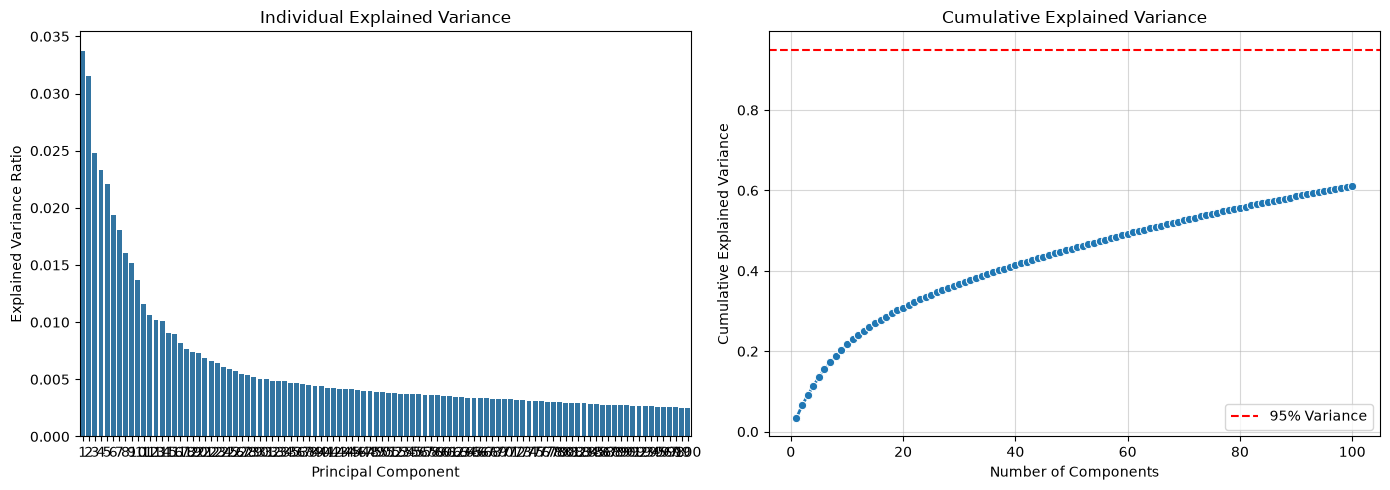

(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Individual Explained Variance'}, xlabel='Principal Component', ylabel='Explained Variance Ratio'>,
        <Axes: title={'center': 'Cumulative Explained Variance'}, xlabel='Number of Components', ylabel='Cumulative Explained Variance'>],
       dtype=object))

In [28]:
PCA_transformer_all_pokemon.scree_plot()

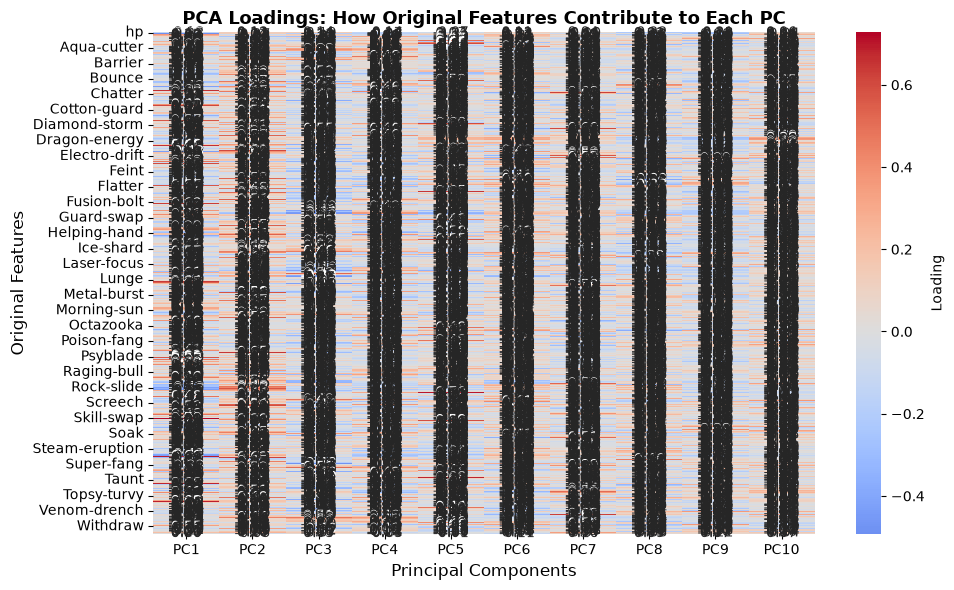

In [24]:
PCA_transformer_all_pokemon.heat_map()

In [29]:
from ipywidgets import FloatSlider, interactive_output, HBox, VBox

sliders = [
    FloatSlider(value=i, min=0, max=len(PCA_transformer_all_pokemon.feature_names), step=1, description=f'PC{i+1}:', continuous_update=False)
    for i in range(2)  # 3 dimensions
]

def update_output(**slider_values):
    slider_dict = {f"PC_{i}":int(slider) for i, (key, slider) in enumerate(slider_values.items())}
    PCA_transformer_all_pokemon.biplot(**slider_dict)

output = interactive_output(update_output, {f'slider{i}': slider for i, slider in enumerate(sliders)})
display(VBox(sliders + [output]))

# PCA_transformer_all_pokemon.biplot(0,1)

In [ ]:
# from scipy.spatial.distance import euclidean

# def find_nearest_in_pca_space(query_point_original, n_components=6):
#     """
#     Find the nearest point in the dataset to a query point in PCA space.
    
#     Parameters:
#     -----------
#     query_point_original : array-like
#         The original feature values for your query point (6 features)
#     n_components : int
#         Number of PCs to use for distance calculation
    
#     Returns:
#     --------
#     dict with nearest neighbor info
#     """
#     # Transform query point to PCA space
#     query_scaled = scalar.transform([query_point_original])
#     query_pca = pca.transform(query_scaled)[:, :n_components]
    
#     # Compare to all points in PCA space
#     distances = np.zeros(len(pca_X))
#     for i, point in enumerate(pca_X[:, :n_components]):
#         distances[i] = euclidean(query_pca[0], point)
    
#     nearest_idx = np.argmin(distances)
#     nearest_name = names[int(nearest_idx)]
#     nearest_distance = distances[int(nearest_idx)]
#     nearest_original = X.loc[int(nearest_idx)]
    
#     return {
#         'index': nearest_idx,
#         'name': nearest_name,
#         'distance_in_pca_space': nearest_distance,
#         'original_features': nearest_original,
#         'pca_coordinates': pca_X[nearest_idx, :n_components]
#     }

c:\dev\workspace\WC_Draft_Prep\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\dev\workspace\WC_Draft_Prep\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



NEAREST NEIGHBOR SEARCH RESULTS
Query point (original features): [100, 50, 75, 60, 80, 45]

Nearest match:
  Name: Azumarill
  Distance in PCA space: 0.2505
  Original features: HP             100
Attack          50
Defense         80
Sp. Attack      60
Sp. Defense     80
Speed           50
Name: 78, dtype: int64


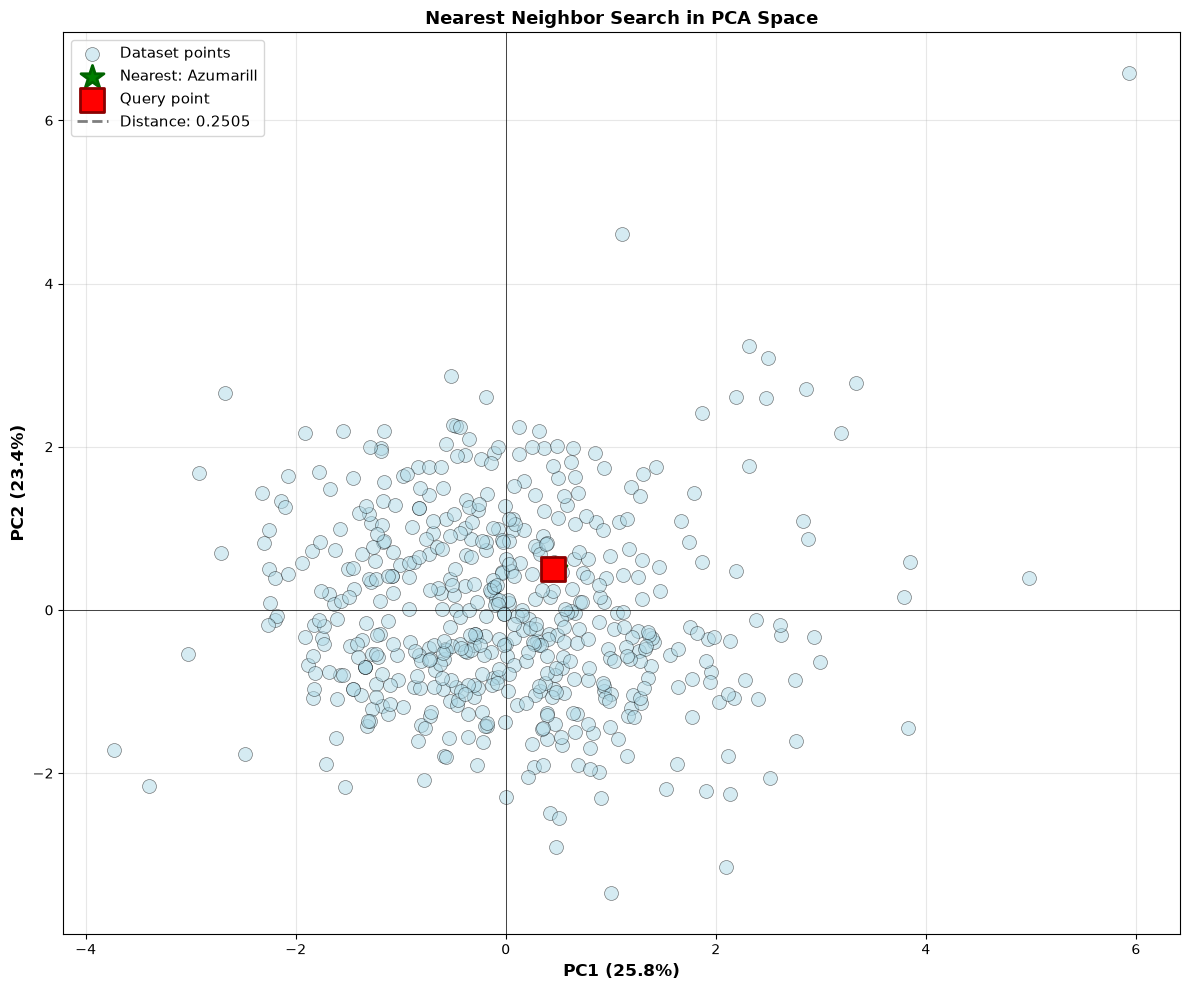

In [ ]:
# # Example: Create a query point (you can modify these values)
# query_features = [100, 50, 75, 60, 80, 45] # Replace with your values

# result = find_nearest_in_pca_space(query_features, n_components=6)

# print("\n" + "="*60)
# print("NEAREST NEIGHBOR SEARCH RESULTS")
# print("="*60)
# print(f"Query point (original features): {query_features}")
# print(f"\nNearest match:")
# print(f"  Name: {result['name']}")
# print(f"  Distance in PCA space: {result['distance_in_pca_space']:.4f}")
# print(f"  Original features: {result['original_features']}")
# print("="*60)

# # Visualize query point and nearest neighbor
# fig, ax = plt.subplots(figsize=(12, 10))

# # Plot all points
# scatter = ax.scatter(pca_X[:, 0], pca_X[:, 1], 
#                      alpha=0.5, s=100, c='lightblue', 
#                      edgecolors='black', linewidth=0.5, label='Dataset points')

# # Highlight nearest neighbor
# ax.scatter(pca_X[result['index'], 0], pca_X[result['index'], 1],
#           s=300, c='green', marker='*', edgecolors='darkgreen', 
#           linewidth=2, label=f'Nearest: {result["name"]}', zorder=5)

# # Plot query point
# query_scaled = scalar.transform([query_features])
# query_pca = pca.transform(query_scaled)
# ax.scatter(query_pca[0, 0], query_pca[0, 1],
#           s=300, c='red', marker='s', edgecolors='darkred', 
#           linewidth=2, label='Query point', zorder=5)

# # Draw line between them
# ax.plot([query_pca[0, 0], pca_X[result['index'], 0]], 
#         [query_pca[0, 1], pca_X[result['index'], 1]], 
#         'k--', linewidth=2, alpha=0.5, label=f'Distance: {result["distance_in_pca_space"]:.4f}')

# ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
# ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
# ax.set_title('Nearest Neighbor Search in PCA Space', fontsize=13, fontweight='bold')
# ax.grid(alpha=0.3)
# ax.axhline(y=0, color='k', linewidth=0.5)
# ax.axvline(x=0, color='k', linewidth=0.5)
# ax.legend(fontsize=11, loc='best')

# plt.tight_layout()
# plt.show()

worth looking into other dimentionality reductions
- linear discriminant analysis
- random projection methods?
- laplacian eigenmaps?
- canonical correlation analysis networks (CCANets)
- generative adversarial networks (GANs) 
- isometric mapping (ISOMAP) (Tenenbaum, de Silva, & Langford, 2000)
- locally linear embedding (LLE) (Roweis & Saul, 2000)
- manifold learning based approaches?